In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker, cm, colors

# Problem 4: Rosenbrock's banana

Let us consider the **Rosenbrock's banana function**  

$$
f(x,y) = (x-1)^2 + 10(y-x^2)^2
$$

Full disclosure on this one- I remembered this problem from the 514 final last semester. I pulled my gradient function from that notebook.

In [3]:
# the Rosenbrock function
def ros(x,y):
    # your code here
    return (x-1)**2+10*(y-x**2)**2

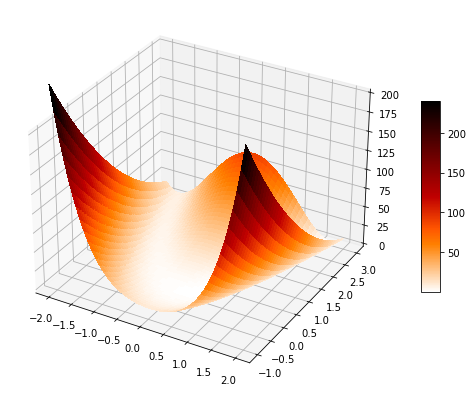

In [4]:
# run this cell to plot the Rosenbrock function

# Initialize figure and axes
from mpl_toolkits import mplot3d
fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection='3d')

# Evaluate Rosenbrock's function
x = np.linspace(-2, 2, 1000) 
y = np.linspace(-1, 3, 1000)
X, Y = np.meshgrid(x, y)
Z = ros(X,Y)

# Plot the surface
surf = ax.plot_surface(X, Y, Z, cmap=cm.gist_heat_r,
                       linewidth=0, antialiased=False)
ax.set_zlim(0, 200)
fig.colorbar(surf, shrink=0.5, aspect=10)
plt.show()

The minimum value of  the Rosenbrock function is zero.
That minimum is reached at the point  (1,1).
This minimum is inside a long, narrow, banana shaped flat valley. 

Text(0.5, 1.0, 'Contour plot of the Rosenbrock function')

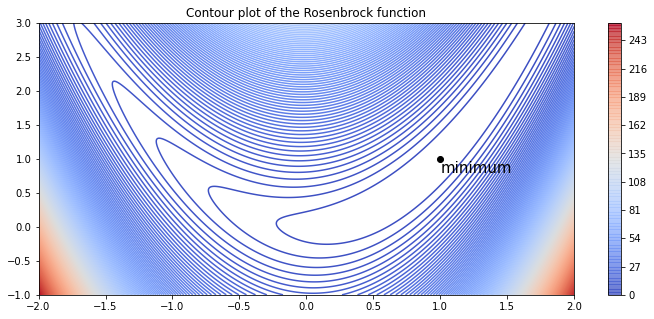

In [5]:
# run this cell to plot the contours of the Rosenbrock function
plt.figure(figsize=(12,5))
plt.contour(X,Y,Z,200, cmap=cm.coolwarm)
plt.plot(1,1,'ko')
plt.annotate('minimum', xy = (1,1),xytext=(1,1-0.2), fontsize=15)
plt.colorbar()
plt.title('Contour plot of the Rosenbrock function')

Find the **gradient** of the Rosenbrock function

$$
\nabla f(x,y) = 
\begin{bmatrix}
\frac{\partial f}{\partial x} \\ \frac{\partial f}{\partial y}
\end{bmatrix}
$$

In [6]:
# gradient of the Rosenbrock's banana function
def grad_ros(x,y):
    
    x_partial = 2*x-2-40*x*y+40*x*x*x
    y_partial = 20*(y-x**2)
    
    return np.array([x_partial,y_partial])

Starting at the point $(x,y)=(-1.25,2.75)$ and using a learning rate $s=0.01$, how many iterations (epochs) does Gradient Descent need to find the minimum?

array([0.97490878, 0.94942383])

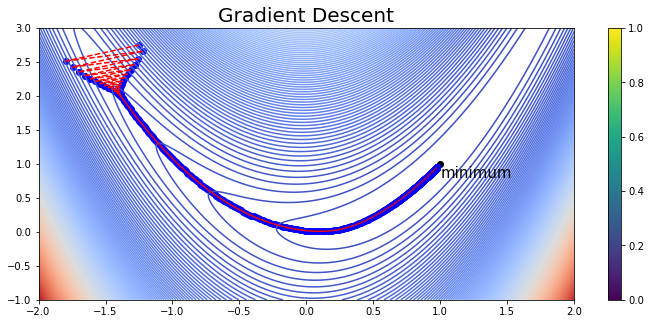

In [18]:
# this cell runs Gradient Descent

plt.figure(figsize=(12,5))
plt.contour(X,Y,Z,cmap=cm.coolwarm, levels=250)
plt.scatter(1,1,color='black')
plt.annotate('minimum', xy = (1,1),xytext=(1,1-0.2), fontsize=15)
plt.colorbar()
plt.title('Gradient Descent',fontsize = 20)

s = 0.01 #learning rate

x = np.array([-1.25,2.75]) # initial point 
plt.scatter(x[0],x[1],color='blue')

######################################
# Set number of epochs
epochs = 800
######################################

for epoch in range(epochs): 
    new_x = x-s*grad_ros(x[0],x[1])
    plt.scatter(new_x[0],new_x[1],color='blue')
    plt.plot([x[0],new_x[0]],[x[1],new_x[1]],'r--')
    x = new_x
    
x

Add momentum to the Gradient Descent method. 
How many epochs does Gradient Descent with Momentum need to find the minimum?

array([0.98896792, 0.97761148])

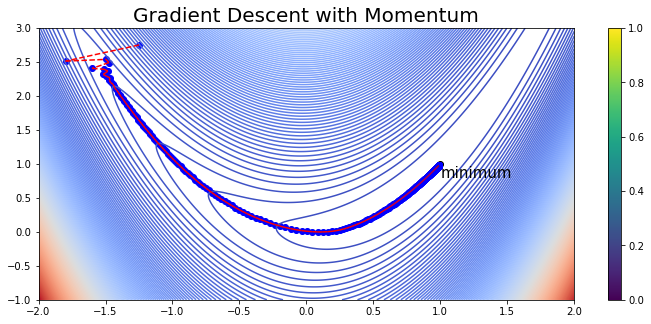

In [24]:
# This cell runs Gradient Descent with Momentum.

plt.figure(figsize=(12,5))
plt.contour(X,Y,Z,cmap=cm.coolwarm, levels=250)
plt.scatter(1,1,color='black')
plt.annotate('minimum', xy = (1,1),xytext=(1,1-0.2), fontsize=15)
plt.colorbar()
plt.title('Gradient Descent with Momentum',fontsize = 20)

# learning rate
s = 0.01 

######################################
# set momentum coefficient
beta  = 0.5
######################################

x = np.array([-1.25,2.75]) # initial point 
plt.scatter(x[0],x[1],color='blue')

######################################
# set number of epochs
epochs = 500
######################################

d_previous = np.array([0,0])

for epoch in range(epochs): 
    
    d_current = -s*grad_ros(x[0],x[1]) + beta*d_previous
    
    new_x = x+d_current
    plt.scatter(new_x[0],new_x[1],color='blue')
    plt.plot([x[0],new_x[0]],[x[1],new_x[1]],'r--')
    x = new_x
    d_previous = d_current
    
x

****

It's sort of unclear to me how to answer these questions- to what degree of precision must we be 'at' the point (1,1)?

In both of these, we are pretty close by some estimates, but in neither case do we 'arrive' at (1,1). Two things are clear though

   1. We are closer to the point (1,1) in 300 fewer epochs using momentum
   2. As shown in the plot, momentum does a great job of curtailing our zig-zagging problem